# (v5) Encoder-Decoder: prediction, masked prediction, generation

### The task and the model

The idea is to train a "language"-like model which could learn patterns in medical histories. For that, medical histories are presented as a flow of diagnoses with correspondent ages at which those were recorded in Electronic Health Records. Input is a csv file in long format, each row contains patient id, age, and a diagnosis. 

As before, words in this language are diagnoses, and age is used for context. 
However, we will try implementing this in two ways: 

1) age for context as in the decoder model in lifejouretys.v4
2) add age representation into the structure of the language, by making one word per year. Years with no diagnoses will be coded with a special "NO DIAGNOSIS" tokem.


**ENCODER-DECODER** models are good for next token (diagnosis) prediction, re-creating missing data in the middle and generation of similar patien stories. 

Difference from the Encoder (v4)

| Component      | Encoder-Only (BERT)                  | Encoder-Decoder (e.g., T5, BART)                |
| -------------- | ------------------------------------ | ----------------------------------------------- |
| Task           | Masked token prediction              | Sequence-to-sequence prediction                 |
| Output         | Same length as input (masked tokens) | Target sequence (e.g. future events)            |
| Attention type | Bidirectional self-attention         | Encoder: bidirectional, Decoder: causal + cross |
| Inference      | Fill-in-the-blanks                   | Generate step-by-step from initial input        |



### Approach we’ll take:

1) Preprocess DataFrame (done): Fill in years with "ND" (No Diagnosis).

2) Define a Token Vocabulary: Include [PAD], [MASK], ND, and all event tokens.

3) Create a Dataset Class: Encoder input = full sequence up to current time, Decoder input = shifted target sequence.

4) Define the model: Transformer encoder-decoder architecture.

5) Training Loop: Teacher forcing setup.

6) Inference: Autoregressive decoding for future events.

### Technical notes (COPIED from v4, need to change):

* The model learns to predict both YEAR_n and event tokens.
* years are numerical and have their own embedding. 
* the main task is for prediction of the middle of the sentence

* Tokens are organised such that [PAD] as ID 0,  [MASK] as ID 1, all unique events from df['event'] start from ID 2
* We prevent the model from predicting 'born' at any age ≠ 0, and mask out that prediction during training and inference by assigning logit = -Inf for "born" at any age>0.
*  **!!** only event loss is minimized (for event_ids), and not for Age (input_ages). Age is only used for the context. (The next version of this code _v5_ has age loss added for age prediction as well.)
 The model uses a BERT-style architecture where we predict *masked event* tokens based on context and the corresponding ages. The loss is computed using nn.CrossEntropyLoss between the model’s output logits (over vocabulary tokens) and the true token labels.

Specifically,
     loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1)).  Here, logits are the model's raw scores for each vocabulary token at each sequence position. labels: the ground truth event tokens (or -100 to ignore when not masked). Positions with label -100 are ignored due to how CrossEntropyLoss handles ignore_index=-100.


### Start 

In [1]:
import numpy as np
import pandas as pd
import math
import random 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import CrossEntropyLoss
from torch.nn.utils.rnn import pad_sequence

import matplotlib.pyplot as plt


In [2]:
# Age Positional Encoding class
class AgePositionalEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def forward(self, age_tensor):
        B, L = age_tensor.size()
        age_tensor = age_tensor.float().unsqueeze(2)

        div_term = torch.exp(
            torch.arange(0, self.d_model, 2, dtype=torch.float32, device=age_tensor.device)
            * (-math.log(10000.0) / self.d_model)
        )
        sinusoid_input = age_tensor / div_term
        pe = torch.zeros(B, L, self.d_model, device=age_tensor.device)
        pe[:, :, 0::2] = torch.sin(sinusoid_input)
        pe[:, :, 1::2] = torch.cos(sinusoid_input)
        
        # Mask out padded positions (age == -1)
        mask = (age_tensor.squeeze(2) != -1).float().unsqueeze(2)
        pe = pe * mask
        
        return pe

In [3]:

# Encoder-Decoder Transformer model
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(512, d_model)
        self.age_encoding = AgePositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first = True)
        decoder_layer = nn.TransformerDecoderLayer(d_model, nhead, batch_first = True)

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers)
        self.output_head = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt, src_age, tgt_age):
        B, S = src.shape
        _, T = tgt.shape
        src_pos = torch.arange(S, device=src.device).unsqueeze(0).expand(B, S)
        tgt_pos = torch.arange(T, device=tgt.device).unsqueeze(0).expand(B, T)

        src_emb = self.token_embedding(src) + self.pos_embedding(src_pos) + self.age_encoding(src_age)
        tgt_emb = self.token_embedding(tgt) + self.pos_embedding(tgt_pos) + self.age_encoding(tgt_age)

        #src_emb = src_emb.transpose(0, 1)
        #tgt_emb = tgt_emb.transpose(0, 1)

        memory = self.encoder(src_emb)
        output = self.decoder(tgt_emb, memory)
        #output = self.output_head(output.transpose(0, 1))
        output = self.output_head(output)
        return output



In [4]:
class EventSeqDataset(Dataset):
    def __init__(self, df, vocab, max_len=256):
        self.samples = []
        self.vocab = vocab
        pad_token = vocab['[PAD]']

        grouped = df.groupby('patid')
        for _, group in grouped:
            group = group.sort_values('age')
            tokens = [vocab[e] for e in group['event']]
            ages = list(group['age'])
            if len(tokens) > 1:
                src = tokens[:-1]
                tgt = tokens[1:]
                src_age = ages[:-1]
                tgt_age = ages[1:]

                src = src[:max_len]
                tgt = tgt[:max_len]
                src_age = src_age[:max_len]
                tgt_age = tgt_age[:max_len]

                self.samples.append((src, tgt, src_age, tgt_age))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src, tgt, src_age, tgt_age = self.samples[idx]
        return torch.tensor(src), torch.tensor(tgt), torch.tensor(src_age), torch.tensor(tgt_age)


In [5]:
## Collate function with padding
def collate_fn(batch):
    srcs, tgts, src_ages, tgt_ages = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=0)
    tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=0)
    src_ages_padded = pad_sequence(src_ages, batch_first=True, padding_value=-1)
    tgt_ages_padded = pad_sequence(tgt_ages, batch_first=True, padding_value=-1)
    return srcs_padded, tgts_padded, src_ages_padded, tgt_ages_padded

In [6]:
def train_encoder_decoder(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for src, tgt, src_age, tgt_age in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        src_age, tgt_age = src_age.to(device), tgt_age.to(device)

        tgt_input = tgt[:, :-1]
        tgt_labels = tgt[:, 1:].contiguous().view(-1)
        tgt_input_age = tgt_age[:, :-1]

        optimizer.zero_grad()
        output = model(src, tgt_input, src_age, tgt_input_age)
        output = output.contiguous().view(-1, output.size(-1))

        loss = criterion(output, tgt_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


In [7]:
def fill_missing_years(df, fill_event='ND'):
    filled_rows = []
    
    for patid, group in df.groupby('patid'):
        group = group.sort_values('age')
        min_age = group['age'].min()
        max_age = group['age'].max()
        
        all_ages = set(range(min_age, max_age + 1))
        recorded_ages = set(group['age'])
        missing_ages = all_ages - recorded_ages

        # Keep existing rows
        filled_rows.append(group)

        # Add ND rows for missing ages
        nd_rows = pd.DataFrame({
            'patid': patid,
            'age': list(missing_ages),
            'event': fill_event
        })
        filled_rows.append(nd_rows)

    result = pd.concat(filled_rows).sort_values(['patid', 'age']).reset_index(drop=True)
    return result

### TRAIN on TOY DATA

In [67]:
# read training data, create main main_vocab from all events in the data, create year_main_vocab from 0 to 110
df = pd.read_csv("long_df.csv")
df = df.assign(patid = df.idauniq)


In [69]:
# moving age by 1 if happens more than once (for 1 token per year rule)
def adjust_duplicate_ages(df):
    df = df.sort_values(by=['patid', 'age'])  # Ensure order
    df['age_original'] = df['age']   # Store original age
    
    df['age'] = df['age_original'].copy()  

    for id_val in df['patid'].unique():  # Process per ID
        seen_ages = set()
        for idx in df[df['patid'] == id_val].index:
            while df.loc[idx, 'age'] in seen_ages:  # Increment if duplicate
                df.loc[idx, 'age'] += 1
            seen_ages.add(df.loc[idx, 'age'])
    df.age = round(df.age,0)
    df['age'] = df['age'].astype(int)
    return df
df = adjust_duplicate_ages(df)


In [70]:
df

,Unnamed: 0,idauniq,event,age,sex,wealth,edu,eth,patid,age_original
0,0,100001,born,0,0,1.000000,1.0,0.0,100001,0.00
1,1,100001,hibp,60,0,1.000000,1.0,0.0,100001,60.00
2,2,100001,diab,61,0,1.000000,1.0,0.0,100001,60.00
3,3,100005,born,0,0,2.500000,1.0,0.0,100005,0.00
4,4,100006,born,0,0,2.333333,1.0,0.0,100006,0.00
...,...,...,...,...,...,...,...,...,...,...
78308,78308,909774,arthr,45,1,5.000000,3.0,0.0,909774,45.25
78309,78309,909775,born,0,1,1.000000,1.0,0.0,909775,0.00
78310,78310,909775,arthr,52,1,1.000000,1.0,0.0,909775,52.25
78311,78311,909775,hrtrhm,53,1,1.000000,1.0,0.0,909775,52.25


In [73]:
df = fill_missing_years(df)

In [74]:
df.head()

,Unnamed: 0,idauniq,event,age,sex,wealth,edu,eth,patid,age_original
0,0.0,100001.0,born,0.0,0.0,1.0,1.0,0.0,100001,0.0
1,NaN,NaN,ND,1.0,NaN,NaN,NaN,NaN,100001,NaN
2,NaN,NaN,ND,2.0,NaN,NaN,NaN,NaN,100001,NaN
3,NaN,NaN,ND,3.0,NaN,NaN,NaN,NaN,100001,NaN
4,NaN,NaN,ND,4.0,NaN,NaN,NaN,NaN,100001,NaN


In [77]:
# create main_vocabulary from all diff words in df.event
unique_events = sorted(df['event'].unique())
vocab = {'[PAD]': 0, '[MASK]': 1, 'ND':2}
for i, event in enumerate(unique_events, start=2):
    vocab[event] = i
    id_to_token = {v: k for k, v in vocab.items()}
vocab_words = [id_to_token[i] for i in id_to_token.keys()]

In [79]:
vocab_words

['[PAD]',
 '[MASK]',
 'ND',
 'angin',
 'arthr',
 'asthma',
 'born',
 'cancr',
 'catract',
 'child_allerg',
 'child_appdcts',
 'child_asthma',
 'child_bones',
 'child_cancer',
 'child_diab',
 'child_epilepsy',
 'child_hdache',
 'child_heart',
 'child_infect',
 'child_psych',
 'child_resp',
 'death',
 'depression',
 'diab',
 'hibp',
 'hip',
 'hrtatt',
 'hrtmr',
 'hrtrhm',
 'hyster',
 'lung',
 'osteo',
 'parkin',
 'psych',
 'strok']

In [106]:
# --- Hyperparameters ---
batch_size = 512
num_epochs = 5
lr = 1e-3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [108]:
# --- Dataset creation ---
dataset = EventSeqDataset(df, vocab)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn = collate_fn)

In [109]:
len(dataloader) # 34

34

In [112]:
model = TransformerEncoderDecoder(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr)

In [ ]:
for epoch in range(num_epochs):
    loss = train_encoder_decoder(model, dataloader, optimizer, criterion, device)
    if (epoch <= 10): 
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")
    else:
        if (epoch%10 == 0):
            print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss:.4f}")

Epoch 1/5 | Loss: 0.4504


tensor([2.5796e-05, 1.4067e-05, 9.5032e-01, 2.9314e-05, 1.0555e-02, 1.6587e-02,
        2.1024e-02, 1.4416e-03])


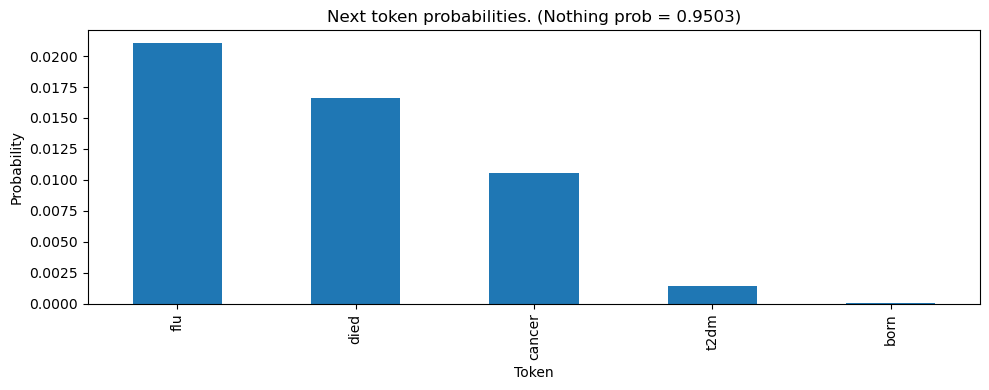

(Text(24.0, 0.5, 'Probability'), Text(0.5, 24.0, 'Token'), None, None)

In [442]:
# checking probabilities for next token 
with torch.no_grad():
    sample = next(iter(dataloader))
    out = model(*[x.to(device) for x in sample])
    print(out[0, -1].softmax(dim=0))  # Probabilities over vocab
probs = out[0,-1].softmax(dim=0).numpy()
prob_dict = {id_to_token[j]: float(probs[j]) for j in range(len(probs))}
nd_prob = round(prob_dict["ND"],4)
prob_dict.pop("[MASK]"), prob_dict.pop("[PAD]"), prob_dict.pop("ND")
pd.Series(prob_dict).sort_values(ascending=False).plot.bar(figsize=(10, 4), title=f"Next token probabilities. (Nothing prob = {nd_prob})")
plt.ylabel("Probability"), plt.xlabel("Token"), plt.tight_layout(), plt.show()
